# SunSim tutorial

This notebook simulates a star with spots and faculae and computes three kinds of observables.

| Section | What is computed | `mode` of `StarSim` |
|---|---|---|
| 3 | Light curve from **low resolution** spectra: one spot, one facula, and several regions (a facula around a spot, the same but re-centred, several latitudes) | `'photometry'` |
| 3 | Spot that grows and decays (evolution law of the radius) | `'photometry'` |
| 3 | Planet transit, alone and over a spot, and two planets | `'photometry'` with `planet=planet(...)` or a list of planets |
| 4 | **Low resolution** spectra during a facula transit, without rotation, and during a planet transit (chromatic transit depth) | `'spectroscopy'` |
| 5 | The same with **high resolution** spectra | `'spectroscopy'` |
| 6 | Disk-integrated quiet photosphere with and without rotation (solar inclination) | `flux_grid` only |
| 7 | **RV, BIS and FWHM** from the CCF, for the same transits as in the photometry, and a planet transit (Keplerian RV + Rossiter-McLaughlin effect, for several spin-orbit angles) | `'ccf'` |

## 1. How the simulation works

**The stellar disc.** The visible disc is cut in `N_rings` concentric rings of equal width, and every ring in cells of similar area (about 2(2N−1)²/π cells in total: 230 for N = 10, 9014 for N = 60). All the cells of a ring have the same projected angle μ (μ = 1 at the disc centre, μ → 0 at the limb), so they share the same limb darkening.

**Three kinds of surface.** The quiet photosphere, the spots and the faculae. For each one you provide the specific intensity spectrum at several values of μ, as a dictionary `{mu: {'wav': wavelengths [A], 'intensity': intensity}}`.

**Grids.** A grid stores, for every cell, the signal that the cell would give if it were entirely quiet, entirely spot or entirely facula:

* `flux_grid` gives one number per ring, i.e. the flux of one cell of the ring (`mode='photometry'`) or one spectrum per cell (`mode='spectroscopy'`). With `stellar_rotation=True` the spectrum of every cell is Doppler shifted by the rotation velocity of the cell.
* `CCF_grid` gives the CCF of every ring (section 7).

**Active regions.** `active_region(typ, size, latitude, longitude)` is a circular spot (`'sp'`) or facula (`'fc'`):

| argument | meaning |
|---|---|
| `typ` | `'sp'` spot, `'fc'` facula |
| `size` | angular radius [deg] |
| `latitude` | despite its name it is the **colatitude** [deg]: 90 = equator, 60 = latitude +30°, 120 = latitude −30° |
| `longitude` | [deg] at t = 0. The star rotates with `rotation_period`: longitude 180° is on the far side at t = 0 and crosses the disc centre at t = P/2 |

Spots and faculae are independent objects (any position, any size). Where they overlap, the spot is on top of the facula. By default the radius is constant and the regions are always present. With `evolution=law`, a function `law(dt, size)` with `dt = t − appearance_time` [days], the radius changes with time (any growth or decay law, see section 3); a radius ≤ 0 means that the region is not there. `lifetime` is not applied yet (it can be included in the law).

**Rotation and differential rotation.** `rotation_period` is the period at the **equator**: the angular velocity there is Ω_eq = 360° / `rotation_period`. Other latitudes can rotate at a different rate. The rotation rate is a polynomial in sin²(latitude), whose coefficients are given in `differential_rotation` [deg/day]:

`Ω(lat) = Ω_eq + c1·sin²(lat) + c2·sin⁴(lat) + ...`,  `differential_rotation = (c1, c2, ...)`

| `differential_rotation` | rotation |
|---|---|
| `0` (default) or `None` | rigid rotation, every latitude has the period `rotation_period` |
| `B` (one number) | Ω = Ω_eq + B sin²(lat) |
| `(B, C)`, `(c1, c2, c3, ...)` | any number of terms |
| `SOLAR_DIFFERENTIAL_ROTATION` = `(-1.698, -2.346)` | the Sun (the law used in StarSim) |

The longitude of a region at time t is `longitude + Ω(lat)·(t − reference_time)`. With the solar law the regions at higher latitude rotate more slowly: a region at latitude 30° lags behind the equator by about 0.57°/day (5.7° after 10 days), and by 2.6°/day at 60°. Negative coefficients, as in the Sun, mean that the poles rotate more slowly than the equator; positive ones (anti-solar differential rotation) that they rotate faster. In this tutorial we use the solar law. Only the regions follow the differential rotation: the rotation velocity of the cells used for the Doppler shifts (`vsini`, `stellar_rotation=True`, ccf mode) is that of a rigid rotation with `rotation_period`.

**StarSim.** At every epoch it computes the position of the regions and, for every cell, the fraction covered by the spot, the facula (and the planet): the *filling factors* `ff`. The signal is then the sum over the cells

`signal = Σ_cells [ ff_quiet · signal_quiet + ff_spot · signal_spot + ff_facula · signal_facula ]`

where the three filling factors of a cell add up to one. `mode` is a list with any of `'photometry'`, `'spectroscopy'` and `'ccf'`; the geometry is computed once per epoch for all of them. The results are `flux_var` (photometry), `spec_var` (spectroscopy), `ccf_var` and its parameters `rv_var`, `fwhm_var`, `bis_var`, `contrast_var` (ccf), and the filling factors `ff_sp`, `ff_fc` (and `ff_pl` for the planet, a `planet` object given with `StarSim(..., planet=...)`) [% of the disc].

**Inclination.** `inclination` [rad] is the angle between the rotation axis and the plane of the sky: 0 is equator-on (the axis is perpendicular to the line of sight, used for the transits below) and π/2 is pole-on. The Sun is seen almost equator-on: its axis is tilted by at most 7.25° (section 6).

## 2. Setup: parameters and spectra

**Any kind of spectra can be used.** SunSim does not depend on a particular set of models. For each kind of surface (quiet photosphere, spot, facula) it only needs a dictionary with the specific intensity spectrum at several values of μ:

```python
{mu: {'wav': wavelengths,        # 1D array [A]
      'intensity': intensity},   # 1D array, same length, specific intensity at this mu
 ...}
```

* the keys are the values of μ, as numbers or strings that can be converted to numbers (`0.1`, `'0.1'`, ..., `1.0`), in any order;
* all the μ of one surface must have the **same wavelength grid**;
* `flux_grid` needs **at least two μ**. The intensity is interpolated linearly between them and extrapolated towards the limb (I ∝ μ) below the smallest one. `CCF_grid` also accepts a single spectrum at μ = 1.0 together with `mu_ratio` (see section 7);
* any units, as long as the three surfaces use the same ones;
* `CCF_grid(..., phoenix_resolution=True)` is a shortcut for spectra on the Phoenix wavelength grid. For any other grid use `phoenix_resolution=False`.

Spectra from any code (MURaM, MPS-ATLAS, Phoenix, observed solar spectra, ...) can therefore be used. Put them in this format and give them to `flux_grid` and `CCF_grid`.

**In this tutorial: MURaM spectra.** The quiet photosphere and the faculae are spectra computed from MURaM 3D MHD simulations of the solar surface (quiet Sun and faculae), at 10 μ angles (0.1 to 1.0). They come both at high resolution (on the Phoenix wavelength grid) and at low resolution. The spot spectrum is built from the quiet MURaM spectra (`av_solar_ssd_10_mu_angles`), multiplied by the ratio of black bodies at `T_quiet − spot_dT` and at `T_quiet`. The low resolution spectra are used for the photometry and for the low resolution spectroscopy, the high resolution ones for the high resolution spectroscopy and for the CCF.

### Using Phoenix models instead

For other stars, or to compare with the MURaM spectra, `spectrum_utils` has two functions that build spectra from the Phoenix models (PHOENIX-ACES-AGSS-COND-2011) at any temperature, logg and metallicity inside the grid of models. Both return the format above:

| function | Phoenix models | result | use it for |
|---|---|---|---|
| `interpolate_phoenix_mu` | SPECINT: specific intensity, low resolution (1 Å) | `{mu: {'wav', 'intensity'}}` at all the μ of the models | `flux_grid`: photometry, low resolution spectroscopy |
| `interpolate_phoenix` | HiRes: disc-integrated flux, high resolution | `{1.0: {'wav', 'intensity'}}`, one spectrum | `CCF_grid(..., mu_ratio=...)` |

```python
# low resolution, several mu (SPECINT models)
flux_quiet_low = interpolate_phoenix_mu('/path/to/Phoenix_SPECINT', temp=T_quiet, logg=4.44, metallicity=0.0,
                                        wavelength_lower_limit=3800, wavelength_upper_limit=8000)
flux_sp_low = interpolate_phoenix_mu('/path/to/Phoenix_SPECINT', temp=T_quiet - spot_dT, logg=4.44, metallicity=0.0,
                                     wavelength_lower_limit=3800, wavelength_upper_limit=8000)

# high resolution, disc-integrated (HiRes models + WAVE_PHOENIX-ACES-AGSS-COND-2011.fits)
quiet_phx = interpolate_phoenix('/path/to/Phoenix_HiRes', temp=T_quiet, logg=4.44, metallicity=0.0,
                                wavelength_lower_limit=5000, wavelength_upper_limit=5100, normalize=False)
```

* **Interpolation.** It is linear in temperature, logg and [Fe/H] between the closest models of the grid. The models are found in the folder and its subfolders (e.g. `Z-0.0/`, `Z-0.5/`, `Z+0.5/`, as on the Phoenix server). If a model needed for the interpolation is missing, or the parameters are outside the grid, the error message gives the name of the file and the download address: HiRes from http://phoenix.astro.physik.uni-goettingen.de/data/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/, SPECINT from https://phoenix.astro.physik.uni-goettingen.de/?page_id=73.
* **Wavelength range.** The spectra are cut between `wavelength_lower_limit` and `wavelength_upper_limit`, plus 1 Å on each side (`overhead`) so that Doppler shifts do not lose information. The HiRes wavelengths are in vacuum, on the Phoenix grid, so `CCF_grid(..., phoenix_resolution=True)` can be used.
* **SPECINT models.** The μ angles are read from the files. Below the smallest one, `flux_grid` extrapolates the intensity linearly to 0 at the limb. The intensity is in erg/s/cm²/cm/sr.
* **HiRes models.** They are disc-integrated spectra, without μ dependence, so the result has a single key, μ = 1.0. In `CCF_grid(..., mu_ratio=...)` the CCF of every ring is then the disc-centre CCF scaled by `mu_ratio`. `normalize=False` gives the Phoenix flux [erg/s/cm²/cm]. With `normalize=True` the flux is divided by its continuum (a 6th degree polynomial fitted to the maximum of the flux in 20 bins). The original flux and the continuum are then also returned (`'flux'`, `'continuum'`), and `plot=True` shows the fit.

#### Faculae with Phoenix: limb brightening

Phoenix has no facular models. A facula is described as a hotter photosphere, a Phoenix spectrum at `T_quiet + facula_T_contrast`. A hotter photosphere is brighter at every μ, but real faculae are almost invisible at the disc centre and bright towards the limb (**limb brightening**). This is added with a temperature excess that depends on μ, `ΔT(μ) = c0 + c1·μ + c2·μ²`, through the bolometric factor

`LB(μ) = ((T_quiet + ΔT(μ)) / T_quiet)⁴`

`spectrum_utils` has three functions for this:

| function | what it does |
|---|---|
| `facula_dT(mu, law, scale)` | ΔT(μ) [K] |
| `limb_brightening_factor(mu, T_photosphere, law, scale)` | LB(μ) |
| `add_limb_brightening(flux, T_photosphere, law, scale)` | multiplies the spectrum at every μ of a `{mu: {'wav', 'intensity'}}` dictionary by LB(μ) (a new dictionary is returned) |

The ΔT law is a parameter:

| `law` | ΔT(μ) [K] | limb (μ = 0) | centre (μ = 1) |
|---|---|---|---|
| `'starsim'` (default, StarSim with `meunier = 0`) | 155 − 290 μ + 128 μ² | 155 K | −7 K |
| `'meunier'` (Meunier et al. 2010, StarSim with `meunier = 1`) | 250.9 − 407.7 μ + 190.9 μ² | 250.9 K | 34.1 K |
| `(c0, c1, c2, ...)` | any polynomial, coefficients in increasing powers of μ | | |
| a function `dT(mu)` | any law | | |

`scale` multiplies ΔT(μ), e.g. `scale = facula_T_contrast / 250.9` rescales the Meunier law to another facular contrast. The factor does not depend on the wavelength. In the old StarSim it was applied to the rings while computing the time series; here it is applied once to the spectra (or to `mu_ratio`), so `StarSim` does not need to know about it.

**Low resolution (`flux_grid`: photometry and spectroscopy).** Apply it to the facula spectra at every μ:

```python
facula_T_contrast = 30                                                       # [K], example
flux_fc_low = interpolate_phoenix_mu('/path/to/Phoenix_SPECINT', temp=T_quiet + facula_T_contrast, logg=4.44,
                                     wavelength_lower_limit=3800, wavelength_upper_limit=8000)
flux_fc_low = add_limb_brightening(flux_fc_low, T_quiet, law='meunier')       # or law='starsim', (c0, c1, c2), dT(mu)
```

**High resolution (`CCF_grid`, ccf mode).** The HiRes facula spectrum is a single disc-centre spectrum, and the CCF of every ring is that CCF scaled by `mu_ratio`. So the limb brightening goes into **`mu_ratio`**, not into the spectrum. The `mu_ratio` of the faculae is the brightness of each ring relative to the quiet disc centre. Computed from low resolution grids that already include the limb brightening (as above), it contains it automatically:

```python
def ring_intensity(flux_low, typ):                                            # intensity of one cell of each ring
    g = flux_grid(N_rings_ccf, flux_low, typ, None, wvm.min(), wvm.max(), mode='photometry')
    g.built_grid()
    return g.grid / g.parea, g.amu

I_quiet, amu_rings = ring_intensity(flux_quiet_low, 'quiet')
I_fc, _ = ring_intensity(flux_fc_low, 'fc')                                   # flux_fc_low with add_limb_brightening
mu_ratio_fc = I_fc / I_quiet[0]
# or, from a mu_ratio computed without limb brightening, add it directly:
# mu_ratio_fc = mu_ratio_fc_without_lb * limb_brightening_factor(amu_rings, T_quiet, law='meunier')

fc_phx = interpolate_phoenix('/path/to/Phoenix_HiRes', temp=T_quiet + facula_T_contrast, logg=4.44,
                             wavelength_lower_limit=wvm.min(), wavelength_upper_limit=wvm.max())
ccf_fac = CCF_grid(N_rings_ccf, fc_phx, rv_grid, wvm, fm, mu_ratio=mu_ratio_fc, phoenix_resolution=True)
ccf_fac.built_grid()
```

Apply the limb brightening only once: either to the low resolution spectra from which `mu_ratio` is computed, or directly to `mu_ratio`, never to both. The two are equivalent up to the interpolation in μ: on the spectra the factor is evaluated at the tabulated μ and interpolated by `flux_grid`, on `mu_ratio` it is evaluated at the exact μ of every ring (the difference is below 0.1 %, and a few 0.1 % for the outermost ring, below the smallest tabulated μ). Do not apply it to the MURaM facular spectra used in this tutorial: they come from simulations of real faculae and already have their own centre-to-limb variation.

In [1]:
import os
os.environ.setdefault('KMP_WARNINGS', '0')   # before numpy: silences the OpenMP 'omp_set_nested deprecated' info
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt

from main import *
from flux_grid import *
from ccf_grid import *
from active_region import *
from planet import *
from spectrum_utils import *        # black_body, mask_weights, ...

In [2]:
##### Star #####
rotation_period = 24.47            # [days] at the equator
stellar_radius = 1                 # [solar radii]
inclination = 0                    # [rad] equator-on, used for the transits (see section 1)
differential_rotation = SOLAR_DIFFERENTIAL_ROTATION   # (B, C) [deg/day] of Omega(lat) = Omega_eq + B sin^2(lat) + C sin^4(lat), see section 1
T_quiet = 5770                     # [K]
spot_dT = 500                      # [K] the spot is cooler than the quiet photosphere by this amount

##### Epochs: one rotation #####
n_times = 60
time = np.linspace(0, rotation_period, n_times)      # [days]

##### Spectra {mu: {'wav': ..., 'intensity': ...}}: quiet photosphere, facula, spot; high and low resolution #####
flux_quiet = np.load('/Users/sophiestucki/Library/CloudStorage/GoogleDrive-stucki@ieec.cat/Shared drives/Exoplanets-Group/MPS-ATLAS spectra/av_solar_ssd_200G_10_mu_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_quiet_low = np.load('/Users/sophiestucki/Documents/poet/mps/av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy', allow_pickle=True).item()

flux_fc = np.load('/Users/sophiestucki/Library/CloudStorage/GoogleDrive-stucki@ieec.cat/Shared drives/Exoplanets-Group/MPS-ATLAS spectra/av_solar_faculae_200G_10_mu_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_fc_low = np.load('/Users/sophiestucki/Documents/poet/mps/av_solar_faculae_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy', allow_pickle=True).item()

flux_sp = np.load('/Users/sophiestucki/Downloads/vxdrift_corrected_ssd_spectra/av_solar_ssd_10_mu_angles_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
flux_sp_low = np.load('/Users/sophiestucki/Downloads/vxdrift_corrected_ssd_spectra/av_solar_ssd_10_mu_angles_PHOENIX_low_res_specint_grid.npy', allow_pickle=True).item()

for mu in flux_sp.keys():
    # the spot is cooler: black-body ratio
    flux_sp[mu]['intensity'] *= black_body(flux_sp[mu]['wav'], (T_quiet-spot_dT)) / black_body(flux_sp[mu]['wav'], T_quiet)
    flux_sp_low[mu]['intensity'] *= black_body(flux_sp_low[mu]['wav'], (T_quiet-spot_dT)) / black_body(flux_sp_low[mu]['wav'], T_quiet)
    # unit conversion of the low resolution spectra (kept from the previous version of the notebook)
    flux_sp_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10) / 1e12
    flux_quiet_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10)/ 1e12
    flux_fc_low[mu]['intensity'] /=  ( 1e-8 * flux_sp_low[mu]['wav']**2 * 2.99792458e10)/ 1e12

print('mu of the spectra:', sorted(flux_quiet.keys()))

mu of the spectra: ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']


In [3]:
def cut_spectra(flux, lo, hi):
    """Keep only the wavelengths between lo and hi [A] of a {mu: {'wav', 'intensity'}} dictionary."""
    out = {}
    for mu, d in flux.items():
        keep = (d['wav'] >= lo) & (d['wav'] <= hi)
        out[mu] = {'wav': d['wav'][keep], 'intensity': d['intensity'][keep]}
    return out


def simulate(regions, mode, N_rings, **grids):
    """StarSim for a list of active regions, with the star seen equator-on. grids: flux_grid_qp / _sp / _fc or ccf_grid_qp / _sp / _fc."""
    ss = StarSim(time, N_rings, inclination=inclination, rotation_period=rotation_period,
                 differential_rotation=differential_rotation, active_regions_map=regions,
                 mode=mode, stellar_radius=stellar_radius, **grids)
    ss.generate_timeseries()
    return ss

## 3. Photometry with low resolution spectra

**Idea.** For photometry only the integrated flux matters, so low resolution spectra are enough. `flux_grid(..., mode='photometry')` interpolates the spectrum at the μ of every ring, integrates it over the wavelength range of the filter (here a box between 3800 and 8000 Å, because `filter_path=None`), and multiplies it by the projected area of the cell. All the cells of a ring have the same flux, so the result is one number per ring (`grid`, the flux of one cell of the ring). `total_brightness` is the sum over the cells (`Ngrid_in_ring @ grid`), the flux of the quiet star.

Three grids are needed: quiet photosphere, facula and spot. Photometry is cheap, so we use 60 rings (about 9000 cells).

At every epoch `StarSim` then computes `flux = Σ_cells ff_quiet·F_quiet + ff_sp·F_spot + ff_fc·F_facula` (`flux_var`). We plot it as `ΔF/F` with respect to the quiet star.

In [4]:
N_rings_phot = 60

def photometry_grid(flux_low, typ):
    g = flux_grid(N_rings_phot, flux_low, typ, None, 3800, 8000, rotation_period=rotation_period, inclination=inclination,
                  stellar_radius=stellar_radius, stellar_rotation=False, mode='photometry')
    g.built_grid()
    return g

flux_grid_quiet = photometry_grid(flux_quiet_low, 'quiet')
flux_grid_fc = photometry_grid(flux_fc_low, 'fc')
flux_grid_sp = photometry_grid(flux_sp_low, 'sp')

### The active regions

Five cases are simulated. All the regions cross the disc during the rotation (the centre of the longitude-180° regions transits at t = P/2), and none is visible at t = 0.

| case | regions |
|---|---|
| `spot` | one spot, radius 10°, on the equator, longitude 180° |
| `facula` | one facula at the same position |
| `facula around a spot` | spot of radius 8° and facula of radius 14° with the same centre: the facula is a ring around the spot |
| `recentred facula` | the same, but the centre of the facula is displaced by 10° in longitude: the spot now sticks out of the facula on one side, so the facula only partly surrounds it (with a displacement smaller than 6° = 14° − 8° the spot would stay inside the facula, off-centre) |
| `several latitudes` | three spot + facula pairs (radius 7° and 12°) at colatitude 60°, 90° and 120° (latitude +30°, 0°, −30°) and longitude 165°, 180° and 195° |

With the solar differential rotation (section 1), the pairs at latitude ±30° of the `several latitudes` case rotate more slowly than the one on the equator: they reach the disc centre a little later than they would with a rigid rotation.

Where the spot is on top of the facula the visible part of the facula is the facula minus the spot. When they only partly overlap, the part of a cell that is covered by the facula and not by the spot is approximated as `facula × (1 − spot)`.

In [5]:
several = []
for colatitude, longitude in [(60, 165), (90, 180), (120, 195)]:
    several += [active_region('sp', 7, colatitude, longitude), active_region('fc', 12, colatitude, longitude)]

scenarios = {
    'spot':                 [active_region('sp', 10, 90, 180)],
    'facula':               [active_region('fc', 10, 90, 180)],
    'facula around a spot': [active_region('sp', 8, 90, 180), active_region('fc', 14, 90, 180)],
    'recentred facula':     [active_region('sp', 8, 90, 180), active_region('fc', 14, 90, 190)],
    'several latitudes':    several,
}

In [6]:
photometry = {}
for name, regions in scenarios.items():
    photometry[name] = simulate(regions, ['photometry'], N_rings_phot,
                                flux_grid_qp=flux_grid_quiet.grid, flux_grid_sp=flux_grid_sp.grid, flux_grid_fc=flux_grid_fc.grid)

def relative_flux(ss):
    """Delta F / F with respect to the quiet star [%]."""
    return 100 * (ss.flux_var / flux_grid_quiet.total_brightness - 1)

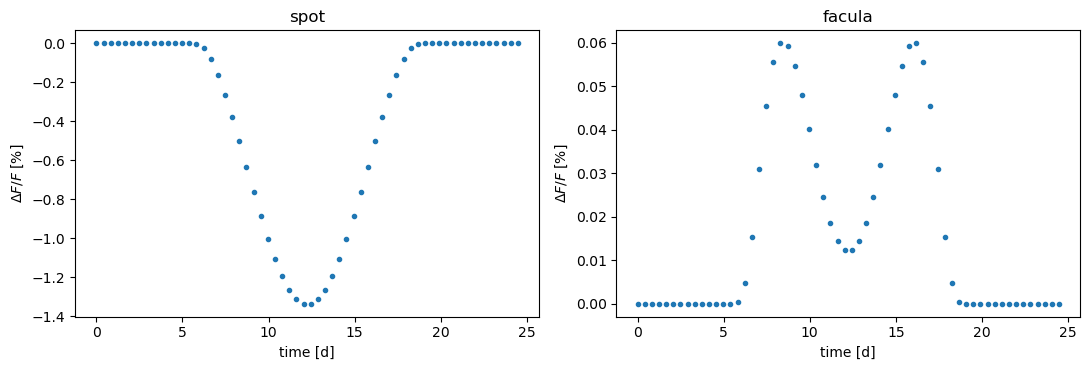

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, name in zip(axes, ['spot', 'facula']):
    ax.plot(photometry[name].obs_times, relative_flux(photometry[name]), '.')
    ax.set_title(name)
    ax.set_xlabel('time [d]')
    ax.set_ylabel('$\\Delta F / F$ [%]')
plt.tight_layout()
plt.show()

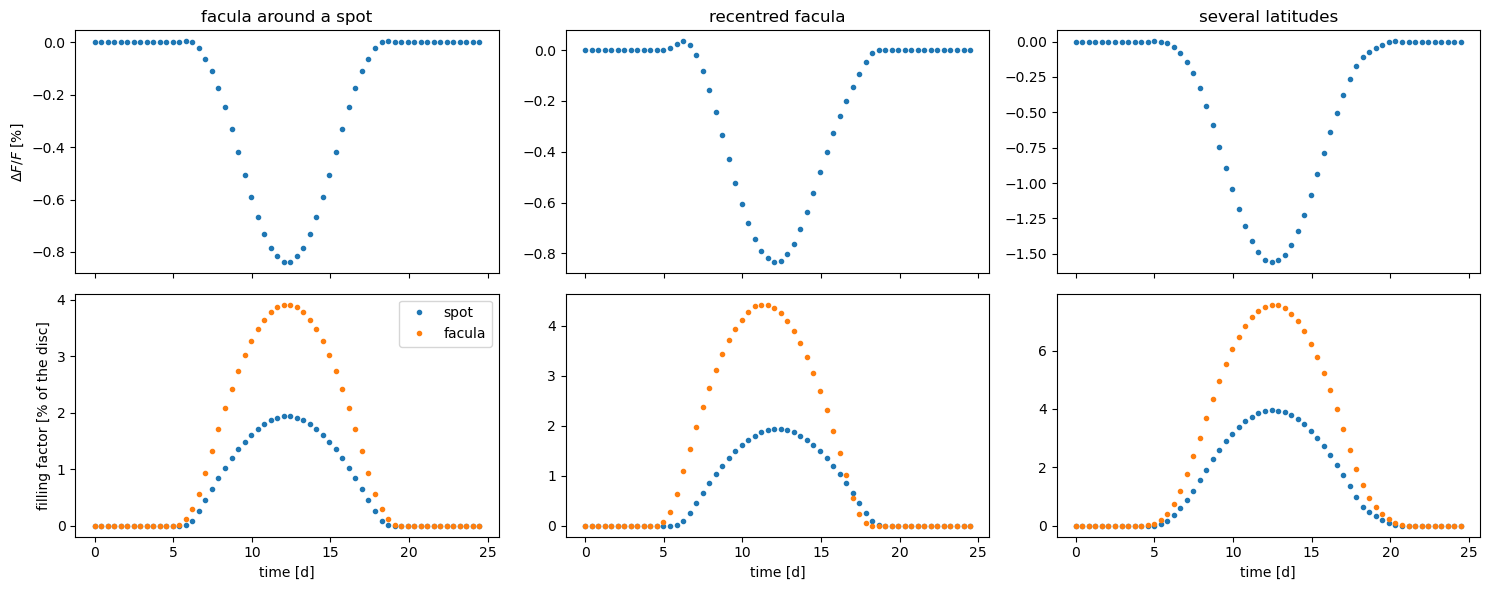

In [8]:
multi = ['facula around a spot', 'recentred facula', 'several latitudes']
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
for j, name in enumerate(multi):
    ss = photometry[name]
    axes[0, j].plot(ss.obs_times, relative_flux(ss), '.')
    axes[0, j].set_title(name)
    axes[1, j].plot(ss.obs_times, ss.ff_sp, '.', label='spot')
    axes[1, j].plot(ss.obs_times, ss.ff_fc, '.', label='facula')
    axes[1, j].set_xlabel('time [d]')
axes[0, 0].set_ylabel('$\\Delta F / F$ [%]')
axes[1, 0].set_ylabel('filling factor [% of the disc]')
axes[1, 0].legend()
plt.tight_layout()
plt.show()

### A spot that grows and decays

By default the radius of a region is constant (`size`). With `active_region(..., evolution=law)` any evolution law can be given: a function `law(dt, size)` that returns the radius [deg], where `dt = t − appearance_time` [days] is an array of times. The function can be written with numpy (vectorised) or for one time at a time (with `if`/`else`, `math`, ...): both work. A radius ≤ 0 (or NaN) simply means that the region is not there at that time, so the law does not need to take care of the times before the appearance or after the disappearance of the region.

Here the **area** of the spot grows linearly during `t_grow` = 4 days and then decays linearly during `t_decay` = 30 days. The linear decay of the area is the Gnevyshev-Waldmeier rule observed for sunspots. The radius is then `size · sqrt(area / maximum area)`. The spot appears at t = 6 d, is at its maximum (10°) at t = 10 d and disappears at t = 40 d. We simulate two rotations: the spot crosses the disc centre at t = P/2 ≈ 12.2 d, when it is almost at its maximum, and again one rotation later, at t ≈ 36.7 d, when it is small. The light curve is compared with that of a spot with a constant radius of 10°. The radius used at every epoch is stored in `regions_pos` (in radians).

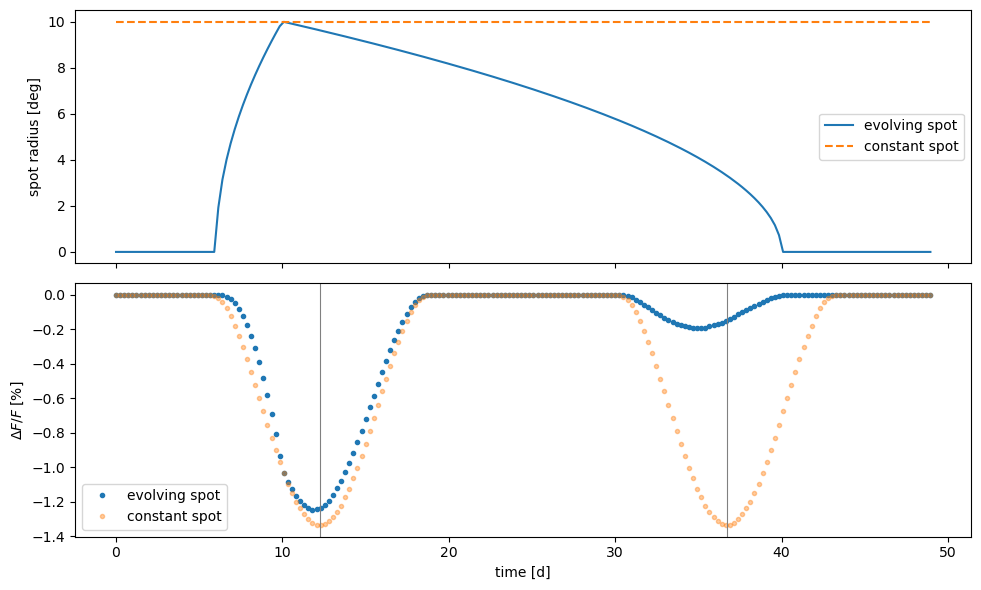

In [9]:
def growth_decay(dt, size, t_grow=4.0, t_decay=30.0):
    """Area growing linearly during t_grow and decaying linearly during t_decay [days]; returns the radius [deg]."""
    area = np.where(dt < t_grow, dt / t_grow, 1 - (dt - t_grow) / t_decay)    # area / maximum area, < 0 outside the life of the spot
    return size * np.sqrt(np.clip(area, 0, None))                               # (clip only because sqrt needs >= 0)

time_evol = np.linspace(0, 2 * rotation_period, 200)                          # two rotations [days]

def simulate_evolution(regions):
    ss = StarSim(time_evol, N_rings_phot, inclination=inclination, rotation_period=rotation_period,
                 differential_rotation=differential_rotation, active_regions_map=regions, mode=['photometry'],
                 stellar_radius=stellar_radius,
                 flux_grid_qp=flux_grid_quiet.grid, flux_grid_sp=flux_grid_sp.grid, flux_grid_fc=flux_grid_fc.grid)
    ss.generate_timeseries()
    return ss

evolving = simulate_evolution([active_region('sp', 10, 90, 180, appearance_time=6, evolution=growth_decay)])
constant = simulate_evolution([active_region('sp', 10, 90, 180)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(time_evol, np.rad2deg(evolving.regions_pos[:, 0, 2]), label='evolving spot')
ax1.plot(time_evol, np.rad2deg(constant.regions_pos[:, 0, 2]), '--', label='constant spot')
ax1.set_ylabel('spot radius [deg]')
ax1.legend()
ax2.plot(time_evol, relative_flux(evolving), '.', label='evolving spot')
ax2.plot(time_evol, relative_flux(constant), '.', alpha=0.4, label='constant spot')
for k in (0.5, 1.5):
    ax2.axvline(k * rotation_period, color='grey', lw=0.8)                    # the spot crosses the disc centre
ax2.set_ylabel('$\\Delta F / F$ [%]')
ax2.set_xlabel('time [d]')
ax2.legend()
plt.tight_layout()
plt.show()

### A transiting planet

A planet is a `planet` object (`planet.py`), given to `StarSim(..., planet=...)`. Several planets are given as a list, `planet=[planet_b, planet_c, ...]`, each with its own orbit, size and spin-orbit angle. `planet=None`, the default, means no planet. `StarSim` then places it in front of the star. The planet is a dark disc: it covers part of the cells (`ff_pl`), and this fraction is removed from the quiet, spot and facula parts of each cell, so that it gives no flux. Its parameters are:

| parameter of `planet(...)` | meaning |
|---|---|
| `planet_period` | orbital period [days] |
| `planet_transit_t0` | time of the centre of the transit [days] |
| `planet_radius` | radius [stellar radii] |
| `planet_semi_major_axis` | semi-major axis [stellar radii] |
| `planet_impact_param` | impact parameter b [stellar radii]: 0 = the planet crosses the disc centre |
| `planet_esinw`, `planet_ecosw` | e·sin ω and e·cos ω (0, 0 = circular orbit) |
| `planet_spin_orbit_angle` | projected spin-orbit angle λ [rad]: angle on the sky between the projected rotation axis of the star and the projected normal of the orbit, i.e. between the stellar equator and the path of the planet on the disc. 0 = aligned prograde orbit, π/2 = polar, π = retrograde |
| `planet_semi_amplitude` | RV semi-amplitude K of the star induced by the planet [m/s]. Only used in `'ccf'` mode: the Keplerian RV `K·[cos(f+ω) + e·cos ω]` (`planet.keplerian_rv`, also stored in `rv_kepler`) is added to `rv_var` |

The `planet` object also gives its position on the disc at any time (`positions(times)`: ρ, θ and radius; `StarSim` stores those of all its planets in `planet_pos`, shape `(n_times, n_planets, 3)`), the Keplerian RV of the star (`keplerian_rv(times)`), the inclination of its orbit (`orbital_inclination()`) and the true (3D) obliquity ψ, the angle between the rotation axis of the star and the normal of the orbit (`obliquity(inclination)`, with cos ψ = cos i★ cos i_p + sin i★ sin i_p cos λ). The simulation needs λ, the angle seen on the sky: ψ alone does not fix the direction of the path of the planet on the disc. With several planets, `ff_pl` is the fraction of the disc covered by all of them and `rv_kepler` the sum of their Keplerian RVs.

Here a planet of 0.1 R* (about Jupiter around the Sun) with a 4 d orbit at a = 10 R* and b = 0, so it crosses the disc along the equator. A transit lasts about 3 hours, much shorter than the 0.4 d step of `time`, so we use a finer time grid around the transit. We centre the transit at t = P_rot/2, when the spot of the `spot` case is at the disc centre, and compare:

* the planet alone, relative to the quiet star: the transit is deeper at the centre than near the limb because of the limb darkening;
* the planet together with the spot, relative to the light curve of the spot alone: when the planet covers the spot it hides a dark region, so less light is lost and the curve rises (the spot crossing).

In [10]:
my_planet = planet(planet_period=4, planet_transit_t0=rotation_period / 2, planet_radius=0.1,
                   planet_semi_major_axis=10, planet_impact_param=0, planet_esinw=0, planet_ecosw=0,
                   planet_spin_orbit_angle=0, planet_semi_amplitude=50)      # K [m/s] is only used in ccf mode (section 7)
time_transit = np.linspace(rotation_period / 2 - 0.12, rotation_period / 2 + 0.12, 121)    # [days]
phot_grids = dict(flux_grid_qp=flux_grid_quiet.grid, flux_grid_sp=flux_grid_sp.grid, flux_grid_fc=flux_grid_fc.grid)

def simulate_transit(regions, with_planet, mode=['photometry'], N_rings=N_rings_phot, grids=phot_grids):
    """StarSim on the transit time grid, with or without the planet."""
    ss = StarSim(time_transit, N_rings, inclination=inclination, rotation_period=rotation_period,
                 differential_rotation=differential_rotation, active_regions_map=regions, mode=mode,
                 stellar_radius=stellar_radius, planet=my_planet if with_planet else None, **grids)
    ss.generate_timeseries()
    return ss

planet_alone = simulate_transit([], True)
spot_alone = simulate_transit(scenarios['spot'], False)
planet_spot = simulate_transit(scenarios['spot'], True)
print('maximum ff_pl = %.2f %% of the disc' % planet_alone.ff_pl.max())

maximum ff_pl = 1.01 % of the disc


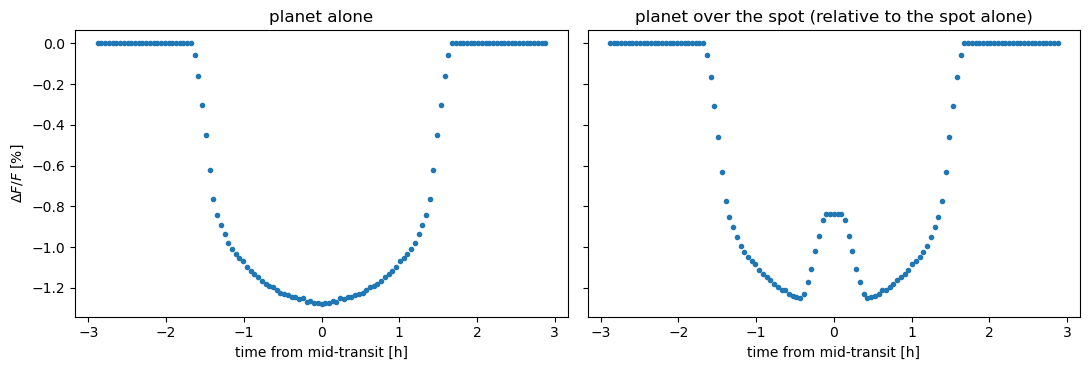

In [11]:
dt_hours = 24 * (time_transit - rotation_period / 2)      # time from the centre of the transit [h]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(dt_hours, relative_flux(planet_alone), '.')
axes[0].set_title('planet alone')
axes[1].plot(dt_hours, 100 * (planet_spot.flux_var / spot_alone.flux_var - 1), '.')
axes[1].set_title('planet over the spot (relative to the spot alone)')
axes[0].set_ylabel('$\\Delta F / F$ [%]')
for ax in axes:
    ax.set_xlabel('time from mid-transit [h]')
plt.tight_layout()
plt.show()

**Two planets.** We add a second, smaller planet c (0.05 R★, P = 6.5 d, b = 0.5) to planet b above, and simulate 16 days with a fine time grid. Planet b transits every 4 days and planet c every 6.5 days. The transit times are chosen so that at t ≈ 12.2 d both planets are in front of the star at the same time. The planets are dark discs; when they overlap each other on the disc (rare), the overlap is counted twice in the cells they share (the occultation of one planet by the other is not modelled).

planet_pos: (3201, 2, 3) (n_times, n_planets, 3)


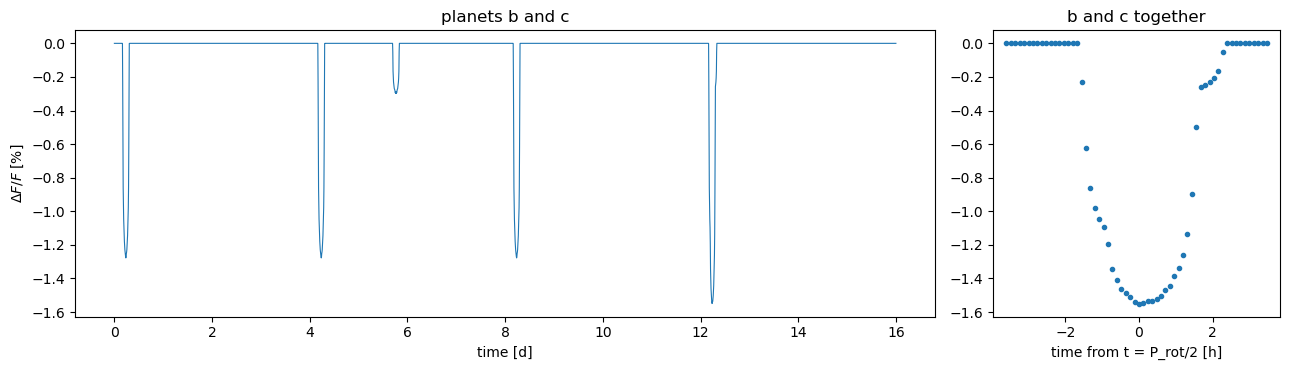

In [12]:
planet_c = planet(planet_period=6.5, planet_transit_t0=rotation_period / 2 + 0.03, planet_radius=0.05,
                  planet_semi_major_axis=14, planet_impact_param=0.5)
time_two = np.linspace(0, 16, 3201)                                            # [days], 7 min steps

two_planets = StarSim(time_two, N_rings_phot, inclination=inclination, rotation_period=rotation_period,
                      mode=['photometry'], stellar_radius=stellar_radius, planet=[my_planet, planet_c], **phot_grids)
two_planets.generate_timeseries()
print('planet_pos:', two_planets.planet_pos.shape, '(n_times, n_planets, 3)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={'width_ratios': [3, 1]})
ax1.plot(time_two, relative_flux(two_planets), lw=0.8)
ax1.set_xlabel('time [d]')
ax1.set_ylabel('$\\Delta F / F$ [%]')
ax1.set_title('planets b and c')
zoom_t = np.abs(time_two - rotation_period / 2) < 0.15                         # simultaneous transits
ax2.plot(24 * (time_two[zoom_t] - rotation_period / 2), relative_flux(two_planets)[zoom_t], '.')
ax2.set_xlabel('time from t = P_rot/2 [h]')
ax2.set_title('b and c together')
plt.tight_layout()
plt.show()

## 4. Low resolution spectroscopy: a facula transit (no rotation)

`flux_grid(..., mode='spectroscopy')` keeps the whole spectrum of every cell instead of integrating it: `grid` has the shape `(n_cells, n_wavelengths)`. With `stellar_rotation=False` all the cells of a ring have the same spectrum (no Doppler shift). `StarSim(mode=['spectroscopy'])` then returns `spec_var`, an array `(n_times, n_wavelengths)` with the disk-integrated spectrum at every epoch.

The grids are much bigger than in photometry, so we use 20 rings (about 1000 cells). We simulate the facula of section 3 and plot, for a few epochs, the spectrum and its relative difference with the spectrum at t = 0, when the facula is on the far side and the star is the quiet one.

In [13]:
N_rings_spec = 60

def spectroscopy_grid(flux, typ, lo, hi):
    """Spectrum of every cell between lo and hi [A], without rotation."""
    g = flux_grid(N_rings_spec, flux, typ, None, lo, hi, rotation_period=rotation_period, inclination=inclination,
                  stellar_radius=stellar_radius, stellar_rotation=False, mode='spectroscopy')
    g.built_grid()
    return g

spec_grid_quiet = spectroscopy_grid(flux_quiet_low, 'quiet', 3800, 8000)
spec_grid_fc = spectroscopy_grid(flux_fc_low, 'fc', 3800, 8000)
spec_grid_sp = spectroscopy_grid(flux_sp_low, 'sp', 3800, 8000)

facula_low = simulate(scenarios['facula'], ['spectroscopy'], N_rings_spec,
                      flux_grid_qp=spec_grid_quiet.grid, flux_grid_sp=spec_grid_sp.grid, flux_grid_fc=spec_grid_fc.grid)
print('spec_var:', facula_low.spec_var.shape, '(n_times, n_wavelengths)')

spec_var: (60, 4199) (n_times, n_wavelengths)


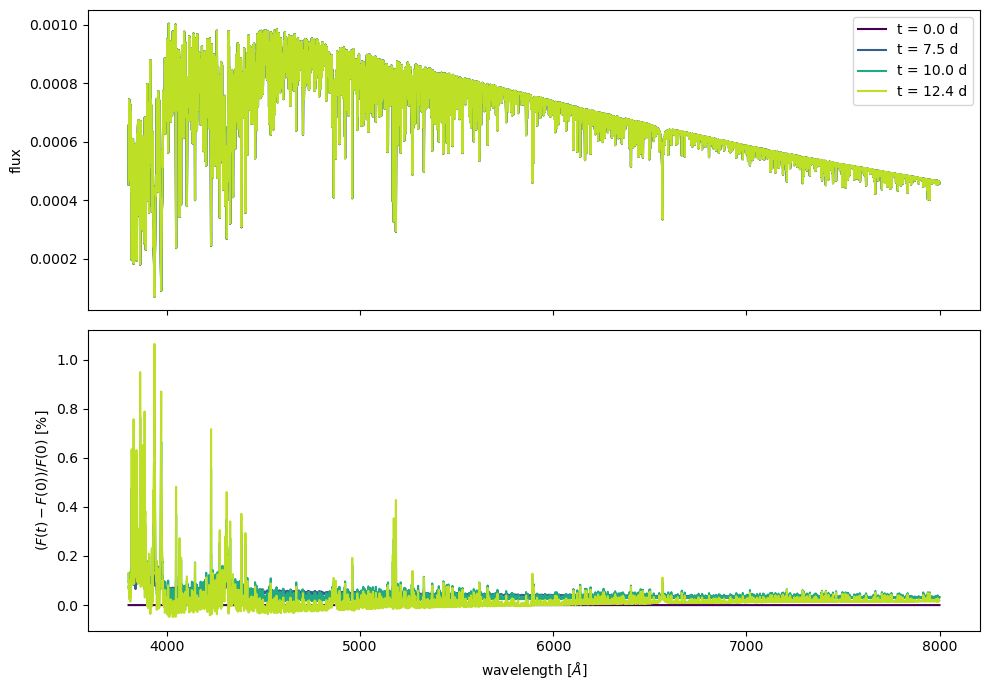

In [14]:
def plot_spectra_and_differences(wv, spec, fractions=(0.0, 0.30, 0.40, 0.50), xlim=None):
    """Spectra at some epochs (given as fractions of the rotation period) and their relative difference with the spectrum at time = 0."""
    idx = [int(np.argmin(np.abs(time - f * rotation_period))) for f in fractions]
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(idx)))
    shown = np.ones(len(wv), dtype=bool) if xlim is None else (wv >= xlim[0]) & (wv <= xlim[1])    # only these wavelengths are plotted
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        for k, color in zip(idx, colors):
            label = 't = %.1f d' % time[k]
            ax1.plot(wv[shown], spec[k][shown], color=color, label=label)
            ax2.plot(wv[shown], 100 * (spec[k][shown] / spec[0][shown] - 1), color=color, label=label)
    ax1.set_ylabel('flux')
    ax2.set_ylabel('$(F(t) - F(0)) / F(0)$ [%]')
    ax2.set_xlabel('wavelength [$\\AA$]')
    ax1.legend()
    if xlim is not None:
        ax1.set_xlim(xlim)
    plt.tight_layout()
    plt.show()

plot_spectra_and_differences(spec_grid_quiet.wv, facula_low.spec_var)

### A planet transit in spectroscopy

The planet of section 3 (0.1 R*, b = 0), now with the spectroscopy grids. The planet blocks the light of the cells it covers, and the limb darkening depends on the wavelength: it is stronger in the blue. So the transit is **chromatic**. At mid-transit the planet covers the bright disc centre and the transit is deeper in the blue. During ingress and egress it covers the limb, which is darker in the blue, so there the transit is deeper in the red.

We plot the light curve integrated over a blue and a red band, and the transit depth `1 − F(t)/F_out` as a function of wavelength at mid-transit and during ingress (`F_out` is the spectrum before the transit). With 20 rings the cells are about 0.08 R* wide, so the edge of the planet is coarse (use more rings for precise transit shapes).

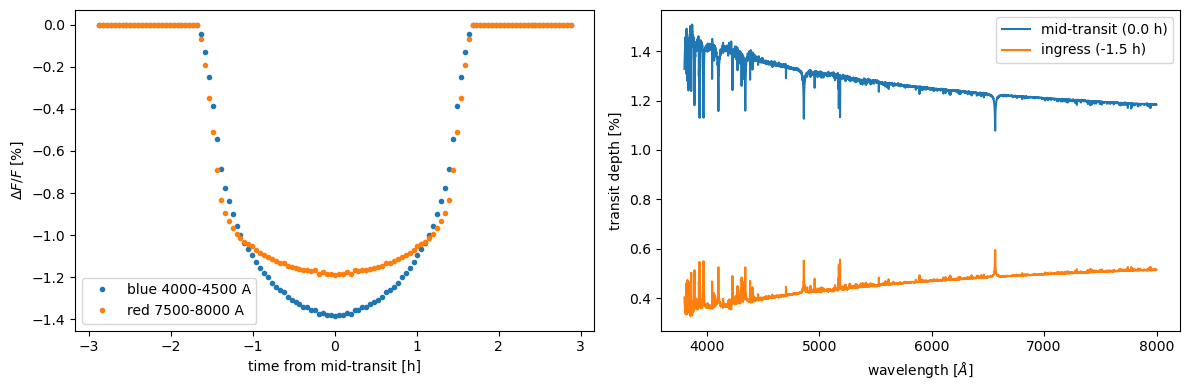

In [15]:
planet_spec = simulate_transit([], True, mode=['spectroscopy'], N_rings=N_rings_spec,
                               grids=dict(flux_grid_qp=spec_grid_quiet.grid, flux_grid_sp=spec_grid_sp.grid, flux_grid_fc=spec_grid_fc.grid))
wv_spec = spec_grid_quiet.wv
F_out = planet_spec.spec_var[0]                         # spectrum before the transit
dt_hours = 24 * (time_transit - rotation_period / 2)    # time from the centre of the transit [h]

bands = {'blue 4000-4500 A': (4000, 4500), 'red 7500-8000 A': (7500, 8000)}
epochs = {'mid-transit': 0.0, 'ingress': -1.5}           # [h] from the centre of the transit

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for label, (lo, hi) in bands.items():
    band = (wv_spec >= lo) & (wv_spec <= hi)
    flux_band = planet_spec.spec_var[:, band].sum(axis=1)       # flux in the band
    ax1.plot(dt_hours, 100 * (flux_band / flux_band[0] - 1), '.', label=label)
ax1.set_xlabel('time from mid-transit [h]')
ax1.set_ylabel('$\\Delta F / F$ [%]')
ax1.legend()
with np.errstate(divide='ignore', invalid='ignore'):
    for label, h in epochs.items():
        k = int(np.argmin(np.abs(dt_hours - h)))
        ax2.plot(wv_spec, 100 * (1 - planet_spec.spec_var[k] / F_out), label='%s (%.1f h)' % (label, dt_hours[k]))
ax2.set_xlabel('wavelength [$\\AA$]')
ax2.set_ylabel('transit depth [%]')
ax2.legend()
plt.tight_layout()
plt.show()

## 5. High resolution spectroscopy: a facula transit (no rotation)

The same with the high resolution spectra. A high resolution spectrum has hundreds of thousands of wavelengths, and `grid` stores one spectrum per cell, so we keep only a small wavelength window (`cut_spectra`) and use 20 rings. The spectra are plotted in a zoom of the window where individual lines can be seen.

In [16]:
N_rings_hr = 20
wl_window = (5000.0, 5004.0)         # [A] part of the spectrum that is simulated
zoom = (5000.25, 5001.2)             # [A] part that is plotted

hr_quiet = cut_spectra(flux_quiet, *wl_window)
hr_fc = cut_spectra(flux_fc, *wl_window)
hr_sp = cut_spectra(flux_sp, *wl_window)

def hr_spectroscopy_grid(flux, typ, stellar_rotation=False, incl=inclination):
    g = flux_grid(N_rings_hr, flux, typ, None, *wl_window, rotation_period=rotation_period, inclination=incl,
                  stellar_radius=stellar_radius, stellar_rotation=stellar_rotation, mode='spectroscopy')
    g.built_grid()
    return g

hr_grid_quiet = hr_spectroscopy_grid(hr_quiet, 'quiet')
hr_grid_fc = hr_spectroscopy_grid(hr_fc, 'fc')
hr_grid_sp = hr_spectroscopy_grid(hr_sp, 'sp')

facula_high = simulate(scenarios['facula'], ['spectroscopy'], N_rings_hr,
                       flux_grid_qp=hr_grid_quiet.grid, flux_grid_sp=hr_grid_sp.grid, flux_grid_fc=hr_grid_fc.grid)
print('spec_var:', facula_high.spec_var.shape, '(n_times, n_wavelengths)')

spec_var: (60, 401) (n_times, n_wavelengths)


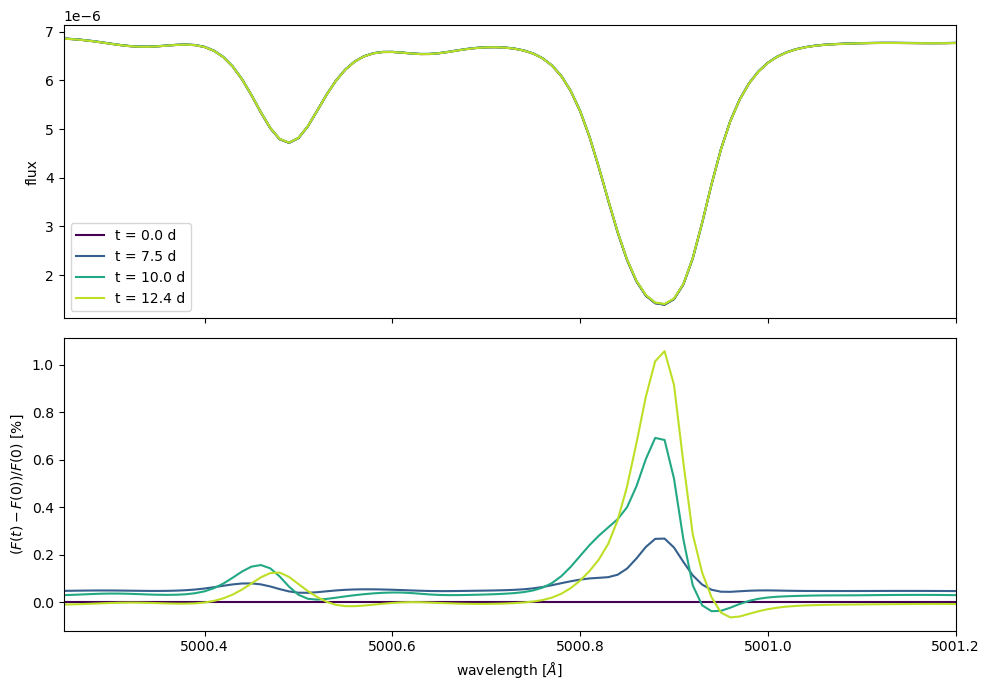

In [17]:
plot_spectra_and_differences(hr_grid_quiet.wv, facula_high.spec_var, xlim=zoom)

## 6. Disk-integrated quiet photosphere, with and without rotation

`flux_grid(..., stellar_rotation=True)` Doppler shifts the spectrum of every cell by the rotation velocity of the cell (`vsini`, the projected equatorial velocity 2πR cos(i) / P with i the inclination defined above, times a factor that depends on the position of the cell), so the disk-integrated spectrum is the sum over the cells of spectra shifted towards the blue on the approaching side and towards the red on the receding side: the lines are broadened. We use the solar inclination, a rotation axis tilted by 7.25° with respect to the plane of the sky, and compare with the spectrum of the same star at rest.

In [18]:
inclination_sun = np.deg2rad(7.25)       # [rad]

grid_rest = hr_spectroscopy_grid(hr_quiet, 'quiet', stellar_rotation=False, incl=inclination_sun)
grid_rot = hr_spectroscopy_grid(hr_quiet, 'quiet', stellar_rotation=True, incl=inclination_sun)

disk_rest = grid_rest.grid.sum(axis=0)       # disk-integrated spectra
disk_rot = grid_rot.grid.sum(axis=0)
print('vsini = %.2f km/s' % (grid_rot.vsini / 1000))

vsini = 2.05 km/s


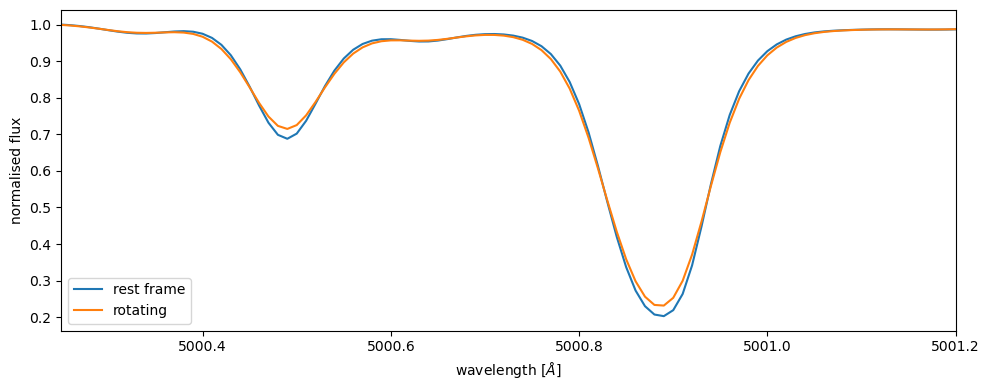

In [19]:
in_rest = (grid_rest.wv >= zoom[0]) & (grid_rest.wv <= zoom[1])      # only the zoom is plotted
in_rot = (grid_rot.wv >= zoom[0]) & (grid_rot.wv <= zoom[1])
norm = disk_rest[in_rest].max()                                       # same normalisation for both spectra

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grid_rest.wv[in_rest], disk_rest[in_rest] / norm, label='rest frame')
ax.plot(grid_rot.wv[in_rot], disk_rot[in_rot] / norm, label='rotating')
ax.set_xlim(zoom)
ax.set_ylabel('normalised flux')
ax.set_xlabel('wavelength [$\\AA$]')
ax.legend()
plt.tight_layout()
plt.show()

## 7. CCF mode: RV, BIS and FWHM

**Idea.** The CCF is the cross-correlation of the spectrum with a mask of lines (here `HARPS_G20_mps_friendly.mas`). `CCF_grid` computes the CCF of the rings. `StarSim(mode=['ccf'])` places the CCF of every ring on the velocity axis, shifted by the rotation velocity of each cell (Doppler shift), and sums over the cells with the filling factors:

`ccf(t) = Σ_cells [ ff_quiet · ccf_quiet + ff_sp · ccf_spot + ff_fc · ccf_facula ]`

Finally `compute_ccf_params` fits a gaussian to every CCF (`rv_var`, `fwhm_var`, `contrast_var`) and computes the bisector span (`bis_var`: mean velocity of the bisector at 10-40 % of the CCF height minus the mean at 60-90 %). All of them are in m/s, except the contrast.

**`CCF_grid` has two steps.** `compute_ccf()` gives the CCF of the rings, `rv_treatment()` the velocity axis on which they are placed, and `built_grid()` runs both.

**Why `mu_ratio`.** The CCF of a ring is normalised to the continuum of its own spectrum, so by itself it does not know that the ring is darker than the disc centre (limb darkening), or that a spot is darker than the photosphere. Without that, a spot would hardly unbalance the rotation of the star and the RV would barely change. With `mu_ratio` the CCF of a ring is multiplied by the brightness of the ring relative to the quiet disc centre. We take these brightness ratios from the low resolution flux grids (same limb darkening, same spot and facula contrast as in the photometry), in the wavelength range of the mask.

**Spectra of the rings.** The high resolution spectra at the 10 μ angles are given to `CCF_grid`: the spectrum of every ring is interpolated between them (and extrapolated towards the limb below μ = 0.1), and its CCF is computed. Every ring therefore keeps the line shape of its own spectrum, and in particular its bisector: the convective blueshift of the quiet photosphere and its reduction in the faculae, and their variation with μ.

**RV treatment.** No bisector is removed: the CCF of every ring is placed at the velocity given by its own spectrum. On top of that a bisector can be added, multiplied by `convective_blueshift`. Here only the spot gets one: the Dumusque bisector, with the polynomial without normalization (`dumusque_bisector(normalization=False)`) and `convective_blueshift = 1`. Nothing is added to the quiet star and the faculae, so their RV changes come from the flux of the regions and from the line shapes of their spectra.

In [20]:
N_rings_ccf = 30
inclination_sun = 0      # [rad]

mask_path = '/Users/sophiestucki/starsim/starsim/masks/HARPS_G20_mps_friendly.mas'
wvm, fm = mask_weights(mask_path)                  # wavelengths [A] and weights of the mask lines
rv_grid = np.arange(-18000, 18025, 25)             # [m/s]

convective_blueshift = {'quiet': 0, 'fc': 0, 'sp': 1}     # factor of the added bisector (0 = none)
bisector = {'quiet': None, 'fc': None,
            'sp': dumusque_bisector(normalization=False)}  # Dumusque bisector, polynomial without normalization

In [21]:
def make_ccf_grid(flux, typ):
    g = CCF_grid(N_rings_ccf, flux, rv_grid, wvm, fm, convective_blueshift=convective_blueshift[typ],
                 phoenix_resolution=True, normalization=False)
    g.built_grid(bisector=bisector[typ])            # compute_ccf() and rv_treatment()
    return g

ccf_quiet = make_ccf_grid(flux_quiet, 'quiet')
ccf_fac = make_ccf_grid(flux_fc, 'fc')
ccf_spot = make_ccf_grid(flux_sp, 'sp')

Now the same five cases as in the photometry. Each simulation returns the CCF of every epoch and its parameters. The reference is the first epoch, when no region is visible (this is checked).

In [22]:
ccf_runs = {}
for name, regions in scenarios.items():
    ss = simulate(regions, ['ccf'], N_rings_ccf, ccf_grid_qp=ccf_quiet, ccf_grid_sp=ccf_spot, ccf_grid_fc=ccf_fac)
    assert ss.ff_sp[0] == 0 and ss.ff_fc[0] == 0, 'a region is visible at t = 0: the first epoch is not the quiet star'
    ccf_runs[name] = ss
print('ccf_var:', ss.ccf_var.shape, '(n_times, n_rv)')

ccf_var: (60, 1441) (n_times, n_rv)


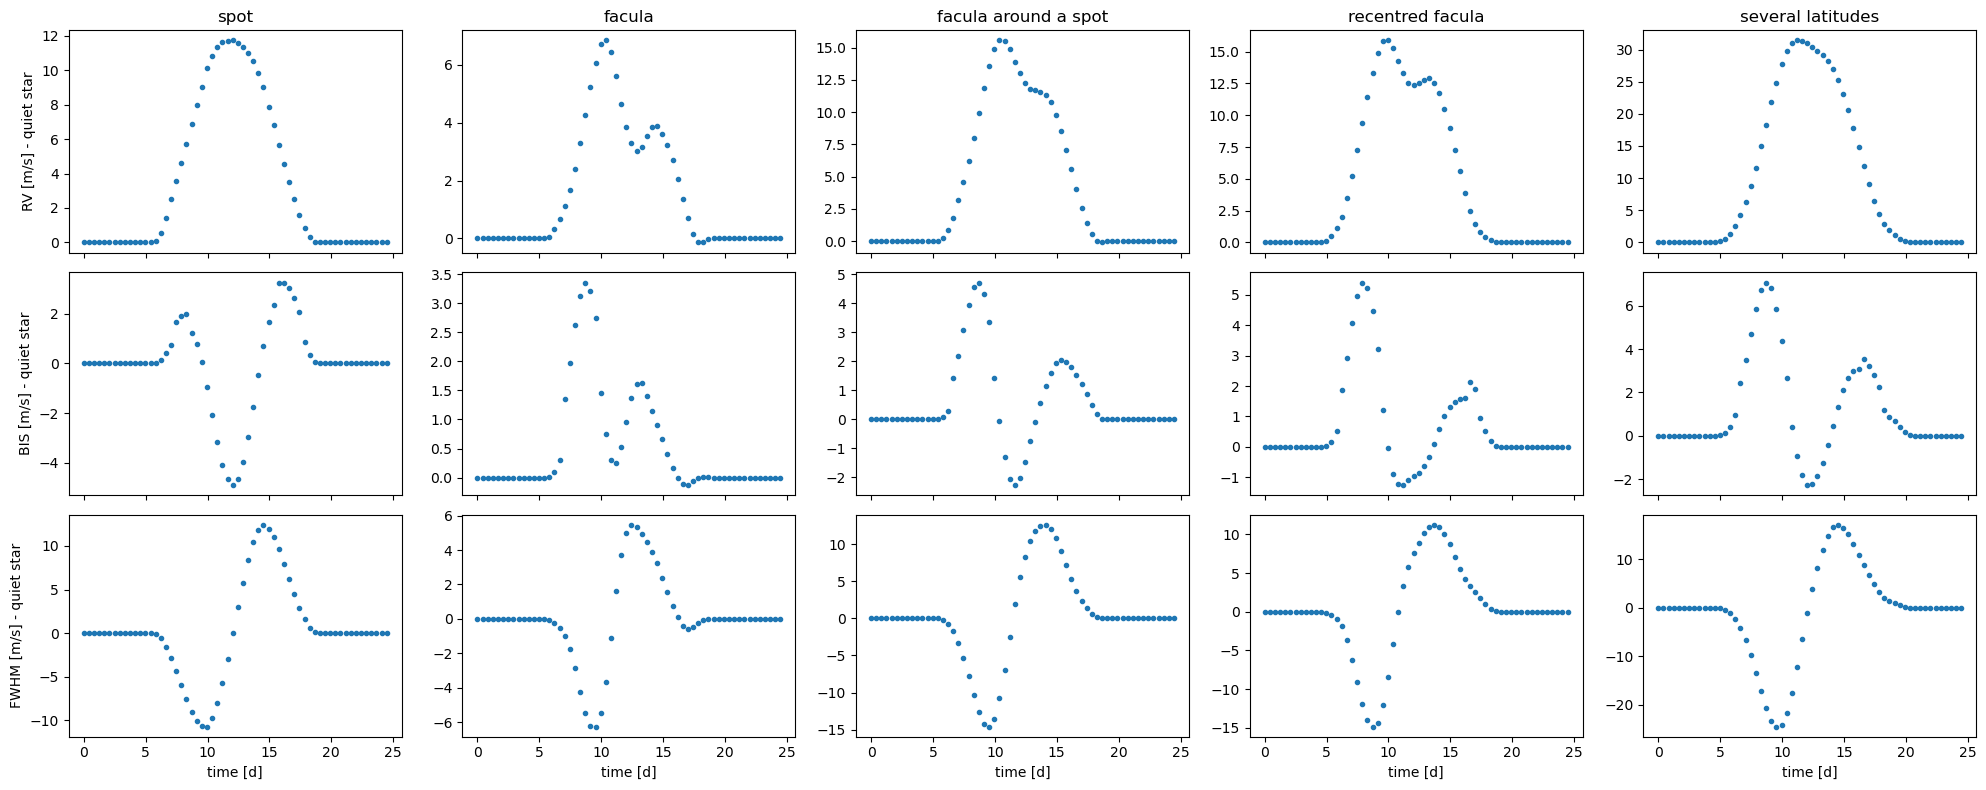

In [23]:
quantities = [('rv_var', 'RV [m/s]'), ('bis_var', 'BIS [m/s]'), ('fwhm_var', 'FWHM [m/s]')]
names = list(scenarios)
fig, axes = plt.subplots(3, len(names), figsize=(4 * len(names), 8), sharex=True)
for j, name in enumerate(names):
    ss = ccf_runs[name]
    for i, (attr, label) in enumerate(quantities):
        values = getattr(ss, attr)
        axes[i, j].plot(ss.obs_times, values - values[0], '.')       # difference with the quiet star (first epoch)
        if j == 0:
            axes[i, j].set_ylabel(label + ' - quiet star')
    axes[0, j].set_title(name)
    axes[-1, j].set_xlabel('time [d]')
plt.tight_layout()
plt.show()

### A planet transit in the CCF: Keplerian RV and Rossiter-McLaughlin effect

The planet of section 3, now in `'ccf'` mode. Its `planet_semi_amplitude = 50` m/s is used here. Two things change the RV:

* **the Keplerian orbit**: `my_planet.keplerian_rv(times)` gives the reflex motion of the star, `K·[cos(f+ω) + e·cos ω]`. It is stored in `rv_kepler` and added to `rv_var`;
* **the Rossiter-McLaughlin effect**: the star rotates, so one half of the disc approaches us (blue shifted) and the other half recedes (red shifted). The planet first hides part of one half and then part of the other, so the CCF loses light first on one side of the line and then on the other: the RV goes up and then down (or the opposite, depending on the direction of the orbit). The amplitude is about (Rp/R*)² · vsini, here 0.01 × 2 km/s ≈ 20 m/s. The planet also changes the shape of the CCF, so the FWHM and the BIS change during the transit.

The reference is the quiet star (first epoch of the CCF runs above). `rv_var − rv_kepler` is the RV without the orbit, i.e. the Rossiter-McLaughlin anomaly alone.

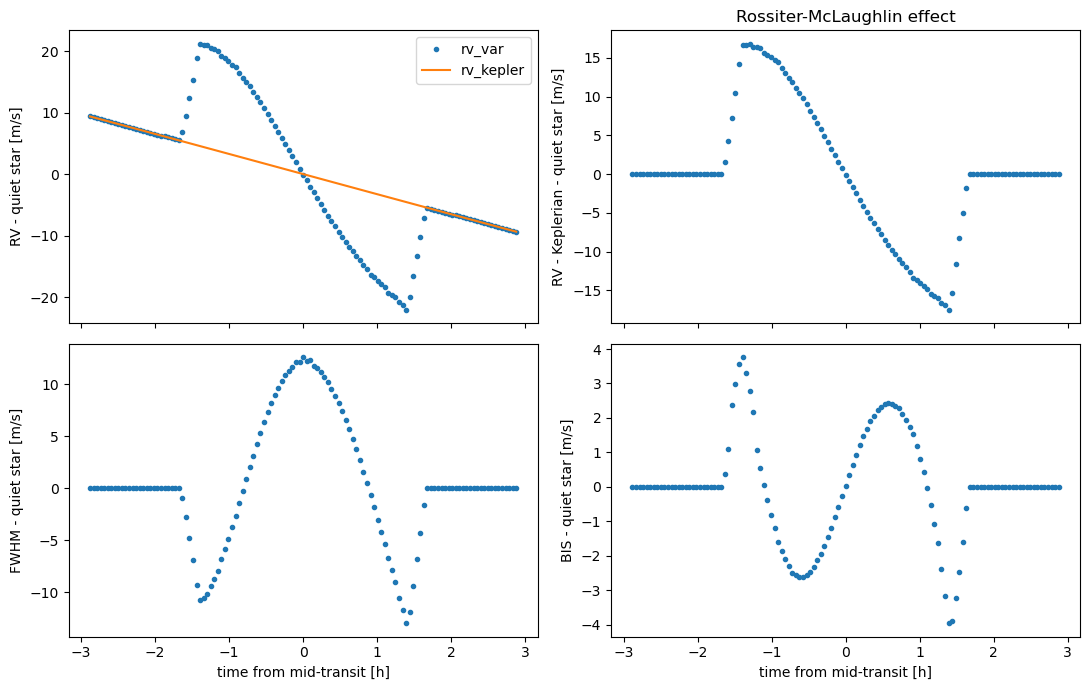

In [24]:
planet_ccf = simulate_transit([], True, mode=['ccf'], N_rings=N_rings_ccf,
                              grids=dict(ccf_grid_qp=ccf_quiet, ccf_grid_sp=ccf_spot, ccf_grid_fc=ccf_fac))
quiet = ccf_runs['spot']                                # its first epoch is the quiet star (checked above)
dt_hours = 24 * (time_transit - rotation_period / 2)    # time from the centre of the transit [h]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes[0, 0].plot(dt_hours, planet_ccf.rv_var - quiet.rv_var[0], '.', label='rv_var')
axes[0, 0].plot(dt_hours, planet_ccf.rv_kepler, '-', label='rv_kepler')
axes[0, 0].set_ylabel('RV - quiet star [m/s]')
axes[0, 0].legend()
axes[0, 1].plot(dt_hours, planet_ccf.rv_var - planet_ccf.rv_kepler - quiet.rv_var[0], '.')
axes[0, 1].set_ylabel('RV - Keplerian - quiet star [m/s]')
axes[0, 1].set_title('Rossiter-McLaughlin effect')
axes[1, 0].plot(dt_hours, planet_ccf.fwhm_var - quiet.fwhm_var[0], '.')
axes[1, 0].set_ylabel('FWHM - quiet star [m/s]')
axes[1, 1].plot(dt_hours, planet_ccf.bis_var - quiet.bis_var[0], '.')
axes[1, 1].set_ylabel('BIS - quiet star [m/s]')
for ax in axes[1]:
    ax.set_xlabel('time from mid-transit [h]')
plt.tight_layout()
plt.show()

**Spin-orbit angle.** The shape of the Rossiter-McLaughlin anomaly depends on the projected spin-orbit angle λ, i.e. on which parts of the rotating disc the planet covers. We use the same planet with b = 0.3 and λ = 0°, 45°, 90° and 180°:

* λ = 0° (aligned, prograde): the planet first covers the approaching half (blue shifted), then the receding half: the RV goes up, then down;
* λ = 45°: the path crosses less of the velocity field, the amplitude is smaller and asymmetric;
* λ = 90° (polar orbit): the path is parallel to the rotation axis, on one side of it (b ≠ 0), so the planet always covers the same kind of velocities: the anomaly has a single sign;
* λ = 180° (retrograde): the opposite of the aligned case.

Left: path of the planet on the disc (`planet_pos`; the rotation axis of the star is vertical). Right: the anomaly. For each planet `obliquity(inclination)` gives the true obliquity ψ (here the star is seen equator-on and the orbit is almost edge-on, so ψ ≈ λ).

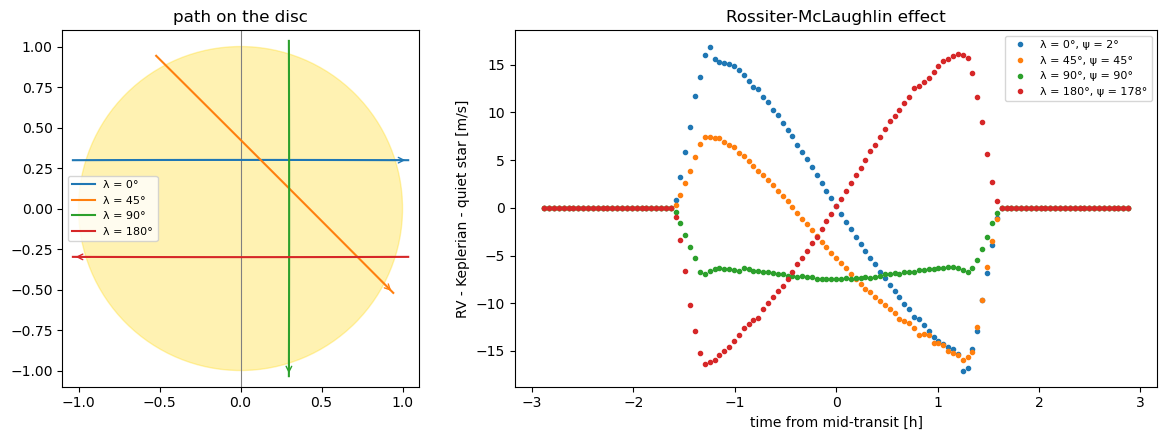

In [25]:
def rm_for_lambda(lam_deg, b=0.3):
    pl = planet(planet_period=4, planet_transit_t0=rotation_period / 2, planet_radius=0.1, planet_semi_major_axis=10,
                planet_impact_param=b, planet_spin_orbit_angle=np.deg2rad(lam_deg))
    ss = StarSim(time_transit, N_rings_ccf, inclination=inclination, rotation_period=rotation_period, mode=['ccf'],
                 stellar_radius=stellar_radius, planet=pl, ccf_grid_qp=ccf_quiet, ccf_grid_sp=ccf_spot, ccf_grid_fc=ccf_fac)
    ss.generate_timeseries()
    return pl, ss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={'width_ratios': [1, 1.6]})
ax1.add_patch(plt.Circle((0, 0), 1, color='gold', alpha=0.3))
ax1.axvline(0, color='grey', lw=0.8)                                           # projected rotation axis
for lam in (0, 45, 90, 180):
    pl, ss = rm_for_lambda(lam)
    rho, theta = ss.planet_pos[:, 0, 0], ss.planet_pos[:, 0, 1]
    on_disc = rho < 1 + pl.planet_radius
    line, = ax1.plot((rho * np.cos(theta))[on_disc], (rho * np.sin(theta))[on_disc], label='λ = %d°' % lam)
    ax1.annotate('', xy=((rho * np.cos(theta))[on_disc][-1], (rho * np.sin(theta))[on_disc][-1]),
                 xytext=((rho * np.cos(theta))[on_disc][-5], (rho * np.sin(theta))[on_disc][-5]),
                 arrowprops=dict(arrowstyle='->', color=line.get_color()))
    ax2.plot(dt_hours, ss.rv_var - ss.rv_kepler - quiet.rv_var[0], '.', color=line.get_color(),
             label='λ = %d°, ψ = %.0f°' % (lam, np.rad2deg(pl.obliquity(inclination))))
ax1.set_aspect('equal')
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax1.set_title('path on the disc')
ax1.legend(fontsize=8)
ax2.set_xlabel('time from mid-transit [h]')
ax2.set_ylabel('RV - Keplerian - quiet star [m/s]')
ax2.set_title('Rossiter-McLaughlin effect')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Going further.**

* To add the convective blueshift, set `convective_blueshift` above (it multiplies the Dumusque bisector) or give another bisector `f(mu) -> p(ccf)` to `built_grid(bisector=...)`, for instance one that depends on μ.
* `CCF_grid(..., mu_ratio=None)` computes the CCF of every ring from its own spectrum (it then needs the spectra at several μ).
* With `instrument='HARPS-N'`, `blaze_function=(wavelengths, blaze)` and `instrumental_efficiency`, the CCF is computed order by order after degrading the spectrum to the resolution of the instrument.